In [69]:
import sys
print(sys.executable)

!{sys.executable} -m pip install pandas numpy pyarrow scikit-learn torch

c:\Users\uvvss\anaconda3\python.exe


In [70]:
import pandas as pd
import numpy as np

print("Pandas OK:", pd.__version__)

Pandas OK: 2.2.3


In [71]:
%pip install pandas numpy pyarrow scikit-learn scipy torch matplotlib

Note: you may need to restart the kernel to use updated packages.


In [72]:
from __future__ import annotations

import random
import math
from dataclasses import dataclass
from typing import Dict, Optional, Tuple, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from scipy.optimize import Bounds, LinearConstraint, minimize
from scipy.spatial import ConvexHull, QhullError

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

In [73]:
import sys
print(sys.executable)

import torch
print(torch.__version__)
print("Torch OK")

c:\Users\uvvss\anaconda3\python.exe
2.12.0+cpu
Torch OK


In [74]:
@dataclass
class RLConfig:
    control_dt_hours: float = 1.0
    episode_hours: int = 168          # 1 week
    price_lookahead_hours: int = 24

    polynomial_degree: int = 3
    random_state: int = 42

    total_steps: int = 3000
    start_steps: int = 500
    update_after: int = 500
    update_every: int = 20
    batch_size: int = 256
    replay_size: int = 200000

    gamma: float = 0.99
    tau: float = 0.005
    policy_lr: float = 3e-4
    q_lr: float = 3e-4
    alpha_lr: float = 3e-4
    hidden_size: int = 256
    device: str = "cpu"

    lambda_cost: float = 1.0
    lambda_backlog: float = 500.0
    lambda_smooth: float = 0.20
    lambda_rl_track: float = 0.10
    lambda_violation: float = 25.0
    max_action_change_gpm: float = 0.75
    recovery_low: float = 0.20      # was 0.48
    recovery_high: float = 0.90     # was 0.82
    lambda_terminal_production: float = 2000.0
    lambda_responsive: float = 0.0  # placeholder, set via cfg block

    # ADD these new fields to the dataclass:
    lambda_terminal_production: float = 2000.0
    bounds_padding_fraction: float = 0.05


cfg = RLConfig()
DEVICE = torch.device(cfg.device)

random.seed(cfg.random_state)
np.random.seed(cfg.random_state)
torch.manual_seed(cfg.random_state)

print("Device:", DEVICE)

Device: cpu


In [ ]:
TIMESTAMP_COL = "Timestamp"

POWER_COL = "RO Power Consumption (W)"
PERM_EC_COL = "RO Overall Permeate EC (uS/cm)"
TEMP_COL = "Temperature (C)"
FEED_EC_COL = "RO Feed EC (uS/cm)"

Q_PERM_COL = "RO Overall Permeate Flowrate (gpm)"
Q_CONC_COL = "RO Overall Concentrate Flowrate (gpm)"
Q_RECIRC_COL = "RO Recirculation Flow Rate (gpm)"

FLOW_COLUMNS = [
    Q_PERM_COL,
    Q_CONC_COL,
    Q_RECIRC_COL,
]

RECOVERY_COL = "Recovery Ratio"

POWER_FEATURES = [
    Q_PERM_COL,
    Q_CONC_COL,
    Q_RECIRC_COL,
    RECOVERY_COL,
]

COMMON_FEATURES = [
    TEMP_COL,
    FEED_EC_COL,
    PERM_EC_COL,
    Q_CONC_COL,
    Q_PERM_COL,
    Q_RECIRC_COL,
    POWER_COL,
]

print("Flow columns:", FLOW_COLUMNS)

Flow columns: ['RO Overall Permeate Flowrate (gpm)', 'RO Overall Concentrate Flowrate (gpm)', 'RO Recirculation Flow Rate (gpm)']


In [76]:
!pip install --upgrade pyarrow

In [77]:
constant_10m = pd.read_parquet("../models/constant_10m_clean.parquet")
varied_10m   = pd.read_parquet("../models/varied_10m_clean.parquet")

constant_10m[TIMESTAMP_COL] = pd.to_datetime(constant_10m[TIMESTAMP_COL])
varied_10m[TIMESTAMP_COL] = pd.to_datetime(varied_10m[TIMESTAMP_COL])

print("Constant:", constant_10m.shape)
print("Varied:", varied_10m.shape)
print(constant_10m.columns.tolist())
print(varied_10m.columns.tolist())

Constant: (1908, 13)
Varied: (981, 12)
['Timestamp', 'n_points', 'Temperature (C)', 'RO IN Feedwater Pressure (psi)', 'RO OUT Concentrate Pressure (psi)', 'RO Feed EC (uS/cm)', 'RO Overall Permeate EC (uS/cm)', 'RO Overall Concentrate EC (uS/cm)', 'RO Overall Concentrate Flowrate (gpm)', 'RO Overall Permeate Flowrate (gpm)', 'RO Recirculation Flow Rate (gpm)', 'RO Power Consumption (W)', 'timestamp']
['Timestamp', 'n_points', 'Temperature (C)', 'RO IN Feedwater Pressure (psi)', 'RO OUT Concentrate Pressure (psi)', 'RO Feed EC (uS/cm)', 'RO Overall Permeate EC (uS/cm)', 'RO Overall Concentrate Flowrate (gpm)', 'RO Overall Permeate Flowrate (gpm)', 'RO Recirculation Flow Rate (gpm)', 'RO Power Consumption (W)', 'timestamp']


In [ ]:
def resample_hourly(df):
    keep_cols = [TIMESTAMP_COL] + [c for c in COMMON_FEATURES if c in df.columns]
    df = df[keep_cols].copy()
    df = df.dropna(subset=[TIMESTAMP_COL])
    df = df.sort_values(TIMESTAMP_COL)

    hourly = (
        df.set_index(TIMESTAMP_COL)
        .resample("1h")
        .mean(numeric_only=True)
        .dropna(how="all")
        .reset_index()
    )

    hourly = hourly.dropna(subset=FLOW_COLUMNS + [POWER_COL]).reset_index(drop=True)
    return hourly

def add_recovery_ratio(df):
    df = df.copy()
    df[RECOVERY_COL] = df[Q_PERM_COL] / (df[Q_PERM_COL] + df[Q_CONC_COL])
    df[RECOVERY_COL] = df[RECOVERY_COL].replace([np.inf, -np.inf], np.nan)
    return df.dropna(subset=[RECOVERY_COL])

constant_hourly = resample_hourly(constant_10m)
varied_hourly = resample_hourly(varied_10m)

constant_hourly = add_recovery_ratio(constant_hourly)
varied_hourly = add_recovery_ratio(varied_hourly)

print("Constant hourly:", constant_hourly.shape)
print("Varied hourly:", varied_hourly.shape)

constant_hourly.head()

Constant hourly: (320, 8)
Varied hourly: (168, 8)


,Timestamp,Temperature (C),RO Feed EC (uS/cm),RO Overall Permeate EC (uS/cm),RO Overall Concentrate Flowrate (gpm),RO Overall Permeate Flowrate (gpm),RO Recirculation Flow Rate (gpm),RO Power Consumption (W)
0,2025-12-04 16:00:00,27.114477,2080.295379,103.101152,0.697756,2.623198,2.003590,1551.002232
1,2025-12-04 17:00:00,27.032298,2101.005027,112.194711,0.698145,2.629192,2.001320,1591.379643
2,2025-12-04 18:00:00,26.905029,2133.925722,113.268903,0.701481,2.628932,1.999936,1607.719758
3,2025-12-04 19:00:00,26.863934,2175.089217,115.959447,0.698547,2.642020,1.999200,1628.153320
4,2025-12-04 20:00:00,26.833334,2219.775541,117.291567,0.700376,2.655527,2.000623,1648.206536


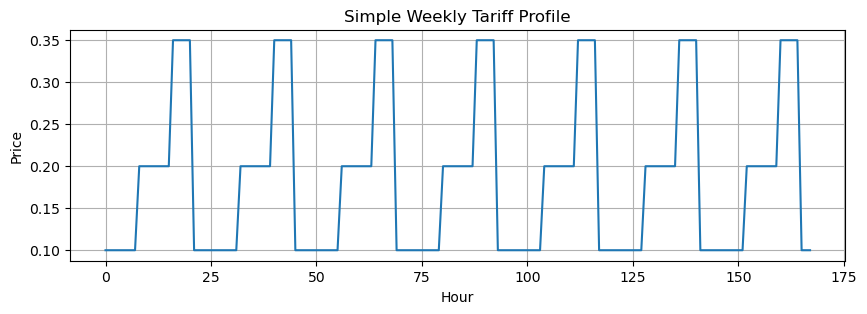

In [79]:
def make_weekly_tariff(episode_hours=168):
    prices = []

    for h in range(episode_hours):
        hour_of_day = h % 24

        if 16 <= hour_of_day < 21:
            price = 0.35   # peak
        elif 8 <= hour_of_day < 16:
            price = 0.20   # mid
        else:
            price = 0.10   # off-peak

        prices.append(price)

    return {
        "simple_tou": np.array(prices, dtype=np.float64)
    }


tariff_profiles = make_weekly_tariff(cfg.episode_hours)

plt.figure(figsize=(10, 3))
plt.plot(tariff_profiles["simple_tou"])
plt.title("Simple Weekly Tariff Profile")
plt.xlabel("Hour")
plt.ylabel("Price")
plt.grid(True)
plt.show()

In [ ]:
class PowerSurrogate:
    def __init__(self, degree=3, random_state=42):
        self.pipeline = Pipeline([
            ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
            ("scaler", StandardScaler()),
            ("lasso", LassoCV(cv=5, random_state=random_state, max_iter=50000))
        ])
        self.metrics = {}

    def fit(self, df):
        X = df[POWER_FEATURES].to_numpy(dtype=np.float64)
        y = df[POWER_COL].to_numpy(dtype=np.float64)

        X_train, X_test, y_train, y_test = train_test_split(
            X, y,
            test_size=0.20,
            random_state=42
        )

        self.pipeline.fit(X_train, y_train)
        pred = self.pipeline.predict(X_test)

        self.metrics = {
            "r2": float(r2_score(y_test, pred)),
            "mae": float(mean_absolute_error(y_test, pred)),
            "rmse": float(np.sqrt(mean_squared_error(y_test, pred))),
        }

        print("Power surrogate metrics:")
        print(self.metrics)

    def predict_watts(self, action_gpm):
        arr = np.asarray(action_gpm, dtype=np.float64)
        arr_2d = np.atleast_2d(arr)

        qp = arr_2d[:, 0]
        qc = arr_2d[:, 1]
        qr = arr_2d[:, 2]
        rr = qp / np.maximum(qp + qc, 1e-6)

        X_pred = np.column_stack([qp, qc, qr, rr])
        pred = self.pipeline.predict(X_pred)
        pred = np.maximum(pred, 0.0)

        if arr.ndim == 1:
            return float(pred[0])
        return pred


power_surrogate = PowerSurrogate(
    degree=cfg.polynomial_degree,
    random_state=cfg.random_state
)

power_surrogate.fit(varied_hourly)

# Extract weighted power equation from surrogate
poly = power_surrogate.pipeline.named_steps["poly"]
lasso = power_surrogate.pipeline.named_steps["lasso"]
feature_names = poly.get_feature_names_out(["Qp", "Qc", "Qr", "RR"])
coefs = lasso.coef_

print("\n── Power Surrogate Equation (top terms) ────────")
print("Power (W) ≈ intercept +")
terms = sorted(zip(np.abs(coefs), coefs, feature_names), reverse=True)
for abs_c, c, name in terms[:10]:
    if abs_c > 0.1:
        print(f"  {c:+.2f} × {name}")
print(f"  intercept: {lasso.intercept_:.2f} W")
print(f"\nSurrogate R²: {power_surrogate.metrics['r2']:.4f}")

Power surrogate metrics:
{'r2': 0.9275096263651529, 'mae': 53.68581819153227, 'rmse': 67.03180438143333}

── Power Surrogate Equation (top terms) ────────
Power (W) ≈ intercept +
  +177.53 × Qp^3
  +95.45 × Qr
  -36.99 × Qr^3
  +21.95 × Qp^2 Qc
  +17.60 × Qp Qc^2
  +9.22 × Qc^3
  intercept: 1713.39 W

Surrogate R²: 0.9275


In [81]:
class FeasibleRegion:
    def __init__(self, points, padding_fraction=0.05):
        self.points = np.asarray(points, dtype=np.float64)

        mins = self.points.min(axis=0)
        maxs = self.points.max(axis=0)
        span = np.maximum(maxs - mins, 1e-6)

        self.low = np.maximum(mins - padding_fraction * span, 0.0)
        self.high = maxs + padding_fraction * span

        self.hull_available = False
        self.A = None
        self.b = None

        try:
            hull = ConvexHull(self.points)
            self.A = hull.equations[:, :-1]
            self.b = -hull.equations[:, -1]
            self.hull_available = True
        except QhullError:
            self.hull_available = False

    def bounds(self):
        return Bounds(self.low, self.high)

    def linear_constraint(self):
        # if not self.hull_available:
        #     return None
        # return LinearConstraint(
        #     self.A,
        #     -np.inf * np.ones_like(self.b),
        #     self.b
        # )
        return None

    def clip(self, action):
        return np.clip(np.asarray(action, dtype=np.float64), self.low, self.high)

    def violation(self, action):
        a = np.asarray(action, dtype=np.float64)

        box_violation = np.sum(
            np.maximum(self.low - a, 0.0) ** 2
            + np.maximum(a - self.high, 0.0) ** 2
        )

        # hull_violation = 0.0
        # if self.hull_available:
        #     hull_violation = np.sum(np.maximum(self.A @ a - self.b, 0.0) ** 2)

        return float(box_violation)


feasible_region = FeasibleRegion(
    varied_hourly[FLOW_COLUMNS].to_numpy(dtype=np.float64),
    padding_fraction=cfg.bounds_padding_fraction
)

print("Action low bounds:", feasible_region.low)
print("Action high bounds:", feasible_region.high)

Action low bounds: [0.81779774 0.22262077 0.89365937]
Action high bounds: [3.24416882 3.23323566 3.23221273]


In [82]:
class DataBundle:
    def __init__(
        self,
        varied_hourly,
        constant_hourly,
        tariff_profiles,
        baseline_action,
        target_total_gal,
        target_hourly_gal,
        feasible_region,
        power_surrogate,
    ):
        self.varied_hourly = varied_hourly
        self.constant_hourly = constant_hourly
        self.tariff_profiles = tariff_profiles
        self.baseline_action = baseline_action
        self.target_total_gal = target_total_gal
        self.target_hourly_gal = target_hourly_gal
        self.feasible_region = feasible_region
        self.power_surrogate = power_surrogate


# ✅ SINGLE canonical DataBundle — delete both old blocks and use only this
QP_BASELINE = 2.7 
QC_BASELINE = 2.6   # gpm  ← ADD
QR_BASELINE = 0.7   # gpm  ← ADD  # gpm
QP_MIN = 1.0
QP_MAX = 3.9

# Lambda weights — backlog dominates, cost competes, smooth/track are minor
# ✅ Replace your lambda block with these balanced values
cfg.lambda_cost                = 50.0
cfg.lambda_backlog             = 800.0
cfg.lambda_smooth              = 5.0
cfg.lambda_rl_track            = 20.0
cfg.lambda_violation           = 25.0
cfg.lambda_terminal_production = 2000.0
cfg.max_action_change_gpm      = 0.75
cfg.recovery_low               = 0.20
cfg.recovery_high              = 0.90
cfg.total_steps                = 50000  # need more steps

baseline_action = constant_hourly[FLOW_COLUMNS].median().to_numpy(dtype=np.float64)
baseline_action[0] = QP_BASELINE  # force PI-defined permeate setpoint
baseline_action[1] = QC_BASELINE   # ← ADD
baseline_action[2] = QR_BASELINE

feasible_region.low[0]  = 1.0    # Qp min
feasible_region.high[0] = 3.9    # Qp max
feasible_region.low[1]  = 0.4    # Qc min  ← ADD
feasible_region.high[1] = 4.9    # Qc max  ← ADD
feasible_region.low[2]  = 0.0    # Qr min  ← ADD
feasible_region.high[2] = 5.0    # Qr max  ← ADD

target_hourly_gal = float(QP_BASELINE * 60.0 * cfg.control_dt_hours)
target_total_gal  = float(target_hourly_gal * cfg.episode_hours)

data = DataBundle(
    varied_hourly=varied_hourly,
    constant_hourly=constant_hourly,
    tariff_profiles=tariff_profiles,
    baseline_action=baseline_action,
    target_total_gal=target_total_gal,
    target_hourly_gal=target_hourly_gal,
    feasible_region=feasible_region,
    power_surrogate=power_surrogate,
)

print("Baseline action [Qp, Qc, Qr]:", data.baseline_action)
print("Target Qp baseline:", data.baseline_action[0])
print("Qp bounds:", data.feasible_region.low[0], data.feasible_region.high[0])
print("Target total gallons:", data.target_total_gal)

Baseline action [Qp, Qc, Qr]: [2.7 2.6 0.7]
Target Qp baseline: 2.7
Qp bounds: 1.0 3.9
Target total gallons: 27216.0


In [83]:
class ROPilotCostEnv:
    def __init__(self, data, cfg):
        self.data = data
        self.cfg = cfg
        self.action_dim = 3
        self.price_lookahead_hours = cfg.price_lookahead_hours
        self.tariff_names = list(data.tariff_profiles.keys())
        self.state_dim = 5 + self.price_lookahead_hours + 3

        # Precompute tariff stats once for normalization
        all_prices = np.concatenate(list(data.tariff_profiles.values()))
        self.price_min = float(all_prices.min())
        self.price_max = float(all_prices.max())
        self.price_mid = (self.price_min + self.price_max) / 2.0

        self.reset()

    def reset(self, tariff_name=None):
        self.t = 0
        self.cumulative_gal = 0.0
        self.prev_action = self.data.baseline_action.copy()
        self.current_action = self.data.baseline_action.copy()
        self.current_power_w = float(
            self.data.power_surrogate.predict_watts(self.current_action)
        )
        self.tariff_name = tariff_name or random.choice(self.tariff_names)
        self.tariff = self.data.tariff_profiles[self.tariff_name].copy()
        return self._get_state()

    def _current_price(self):
        return float(self.tariff[min(self.t, len(self.tariff) - 1)])

    def _price_lookahead(self):
        prices = []
        for k in range(self.price_lookahead_hours):
            idx = min(self.t + k, len(self.tariff) - 1)
            prices.append(self.tariff[idx])
        return np.asarray(prices, dtype=np.float32)

    def _get_state(self):
        price_now = self._current_price()
        produced_frac = self.cumulative_gal / max(self.data.target_total_gal, 1e-6)
        remaining_frac = (
            max(self.data.target_total_gal - self.cumulative_gal, 0.0)
            / max(self.data.target_total_gal, 1e-6)
        )
        time_frac = (self.cfg.episode_hours - self.t) / max(self.cfg.episode_hours, 1)
        state = np.concatenate([
            self.current_action.astype(np.float32),
            np.array([self.current_power_w, price_now], dtype=np.float32),
            self._price_lookahead(),
            np.array([produced_frac, remaining_frac, time_frac], dtype=np.float32),
        ])
        return state.astype(np.float32)

    def sample_random_action(self):
        return np.random.uniform(-1.0, 1.0, size=self.action_dim).astype(np.float32)

    def _raw_to_physical(self, raw_action):
        raw = np.asarray(raw_action, dtype=np.float64)
        raw = np.clip(raw, -1.0, 1.0)
        low = self.data.feasible_region.low
        high = self.data.feasible_region.high
        return low + 0.5 * (raw + 1.0) * (high - low)

    def _constraint_penalty(self, action):
        action = np.asarray(action, dtype=np.float64)
        penalty = self.data.feasible_region.violation(action)
        q_perm, q_conc, q_recirc = action
        recovery = q_perm / max(q_perm + q_conc, 1e-6)
        penalty += max(self.cfg.recovery_low - recovery, 0.0) ** 2
        penalty += max(recovery - self.cfg.recovery_high, 0.0) ** 2
        return float(penalty)

    def _production_deviation(self, q_perm_gpm):
        """Symmetric deviation from cumulative production reference."""
        next_cum = self.cumulative_gal + q_perm_gpm * 60.0 * self.cfg.control_dt_hours
        next_ref = self.data.target_total_gal * ((self.t + 1) / self.cfg.episode_hours)
        signed_dev = (next_cum - next_ref) / max(self.data.target_total_gal, 1e-6)
        # Symmetric: both over and under penalized equally
        # Agent must go high during cheap AND low during expensive to stay on target
        return float(signed_dev ** 2)

    def _price_responsive_reward(self, q_perm, price):
        """
        Core load-shifting incentive.
        cheap hour  + high Qp → POSITIVE reward (negative penalty)
        expensive hour + low Qp → POSITIVE reward (negative penalty)
        """
        # Normalize price: 0.10 → -1.0, 0.225 → 0.0, 0.35 → +1.0
        price_norm = (price - self.price_mid) / max(
            (self.price_max - self.price_min) / 2.0, 1e-6
        )
        # Normalize Qp deviation from baseline
        baseline_qp = self.data.baseline_action[0]  # 2.7
        qp_range = self.data.feasible_region.high[0] - self.data.feasible_region.low[0]
        qp_norm = (q_perm - baseline_qp) / max(qp_range / 2.0, 1e-6)

        # When cheap (price_norm < 0) and high Qp (qp_norm > 0): product < 0 = reward
        # When expensive (price_norm > 0) and low Qp (qp_norm < 0): product < 0 = reward
        # We SUBTRACT this from the penalty (double negative = reward)
        return float(price_norm * qp_norm)

    def _optimize_safe_action(self, raw_physical):
        raw_physical = self.data.feasible_region.clip(raw_physical)
        price = self._current_price()
        prev_action = self.prev_action.copy()
        max_jump = self.cfg.max_action_change_gpm

        local_low = np.maximum(self.data.feasible_region.low, prev_action - max_jump)
        local_high = np.minimum(self.data.feasible_region.high, prev_action + max_jump)

        # Hard floor: never go below 60% of baseline Qp
        min_qp_hard = float(self.data.baseline_action[0]) * 0.60
        local_low[0] = max(local_low[0], min_qp_hard)

        baseline_qp = self.data.baseline_action[0]
        price_norm = (price - self.price_mid) / max(
            (self.price_max - self.price_min) / 2.0, 1e-6
        )
        qp_range = self.data.feasible_region.high[0] - self.data.feasible_region.low[0]

        def objective(x):
            q = np.asarray(x, dtype=np.float64)
            power_kw = float(self.data.power_surrogate.predict_watts(q)) / 1000.0
            step_cost = price * power_kw * self.cfg.control_dt_hours
            deviation = self._production_deviation(q[0])
            smooth = float(np.sum((q - prev_action) ** 2))
            rl_track = float(np.sum((q - raw_physical) ** 2))
            violation = self._constraint_penalty(q)

            # Price-responsive term in safety layer too
            qp_norm = (q[0] - baseline_qp) / max(qp_range / 2.0, 1e-6)
            responsive = price_norm * qp_norm

            return (
                self.cfg.lambda_cost       * step_cost
                + self.cfg.lambda_backlog  * deviation
                + self.cfg.lambda_smooth   * smooth
                + self.cfg.lambda_rl_track * rl_track
                + self.cfg.lambda_violation * violation
                + 200.0                    * responsive  # fixed weight in safety layer
            )

        constraints = []
        hull_constraint = self.data.feasible_region.linear_constraint()
        if hull_constraint is not None:
            constraints.append(hull_constraint)

        x0 = np.clip(raw_physical, local_low, local_high)
        try:
            result = minimize(
                objective,
                x0=x0,
                method="SLSQP",
                bounds=Bounds(local_low, local_high),
                constraints=constraints,
                options={"maxiter": 200, "ftol": 1e-8, "disp": False},
            )
            if result.success:
                return np.asarray(result.x, dtype=np.float64)
        except Exception:
            pass
        return np.clip(x0, local_low, local_high)

    def step(self, raw_action):
        raw_physical = self._raw_to_physical(raw_action)
        action = self._optimize_safe_action(raw_physical)
        action = self.data.feasible_region.clip(action)

        q_perm, q_conc, q_recirc = action
        power_w   = float(self.data.power_surrogate.predict_watts(action))
        power_kw  = power_w / 1000.0
        water_gal = float(q_perm * 60.0 * self.cfg.control_dt_hours)
        price     = self._current_price()
        step_cost = float(price * power_kw * self.cfg.control_dt_hours)
        smooth    = float(np.sum((action - self.prev_action) ** 2))
        violation = self._constraint_penalty(action)
        deviation = self._production_deviation(q_perm)

        # Price-responsive: cheap+highQp = reward, expensive+lowQp = reward
        responsive = self._price_responsive_reward(q_perm, price)

        # Terminal penalty — fires only on the last step
        terminal_prod_penalty = 0.0
        if self.t == self.cfg.episode_hours - 1:
            final_cum = self.cumulative_gal + water_gal
            signed_final = (
                (final_cum - self.data.target_total_gal)
                / max(self.data.target_total_gal, 1e-6)
            )
            terminal_prod_penalty = float(4.0 * signed_final ** 2) if signed_final < 0 \
                else float(signed_final ** 2)

        reward = -(
            self.cfg.lambda_cost                  * step_cost
            + self.cfg.lambda_backlog             * deviation
            + self.cfg.lambda_smooth              * smooth
            + self.cfg.lambda_violation           * violation
            + self.cfg.lambda_terminal_production * terminal_prod_penalty
            + 500.0                               * responsive  # strong explicit coupling
        )

        self.cumulative_gal += water_gal
        self.prev_action     = action.copy()
        self.current_action  = action.copy()
        self.current_power_w = power_w
        self.t  += 1
        done     = self.t >= self.cfg.episode_hours
        next_state = self._get_state()

        info = {
            "tariff_name":           self.tariff_name,
            "q_perm_gpm":            float(q_perm),
            "q_conc_gpm":            float(q_conc),
            "q_recirc_gpm":          float(q_recirc),
            "power_w":               float(power_w),
            "power_kw":              float(power_kw),
            "price":                 float(price),
            "step_cost":             float(step_cost),
            "water_gal":             float(water_gal),
            "cumulative_gal":        float(self.cumulative_gal),
            "target_total_gal":      float(self.data.target_total_gal),
            "backlog":               float(deviation),
            "smooth_penalty":        float(smooth),
            "violation_penalty":     float(violation),
            "terminal_prod_penalty": float(terminal_prod_penalty),
            "recovery":              float(q_perm / max(q_perm + q_conc, 1e-6)),
        }

        return next_state, float(reward), done, info

In [84]:
env = ROPilotCostEnv(data, cfg)

state = env.reset()
print("State dim:", env.state_dim)
print("Action dim:", env.action_dim)
print("Initial state shape:", state.shape)

raw_action = env.sample_random_action()
next_state, reward, done, info = env.step(raw_action)

print("Raw action:", raw_action)
print("Reward:", reward)
print("Done:", done)
print(info)

State dim: 32
Action dim: 3
Initial state shape: (32,)
Raw action: [-0.25091976  0.90142864  0.4639879 ]
Reward: 239.43394123048844
Done: False
{'tariff_name': 'simple_tou', 'q_perm_gpm': 3.4499999999516833, 'q_conc_gpm': 3.349999999988255, 'q_recirc_gpm': 1.4499999999790816, 'power_w': 2149.4122639606494, 'power_kw': 2.149412263960649, 'price': 0.1, 'step_cost': 0.21494122639606494, 'water_gal': 206.99999999710099, 'cumulative_gal': 206.99999999710099, 'target_total_gal': 27216.0, 'backlog': 2.7338610337733396e-06, 'smooth_penalty': 1.6874999998785292, 'violation_penalty': 0.0, 'terminal_prod_penalty': 0.0, 'recovery': 0.5073529411738464}


In [85]:
class ReplayBuffer:
    def __init__(self, state_dim, action_dim, size):
        self.state = np.zeros((size, state_dim), dtype=np.float32)
        self.action = np.zeros((size, action_dim), dtype=np.float32)
        self.reward = np.zeros((size, 1), dtype=np.float32)
        self.next_state = np.zeros((size, state_dim), dtype=np.float32)
        self.done = np.zeros((size, 1), dtype=np.float32)

        self.ptr = 0
        self.size = 0
        self.max_size = size

    def add(self, state, action, reward, next_state, done):
        self.state[self.ptr] = state
        self.action[self.ptr] = action
        self.reward[self.ptr] = reward
        self.next_state[self.ptr] = next_state
        self.done[self.ptr] = float(done)

        self.ptr = (self.ptr + 1) % self.max_size
        self.size = min(self.size + 1, self.max_size)

    def sample(self, batch_size, device):
        idx = np.random.randint(0, self.size, size=batch_size)

        return {
            "state": torch.as_tensor(self.state[idx], device=device),
            "action": torch.as_tensor(self.action[idx], device=device),
            "reward": torch.as_tensor(self.reward[idx], device=device),
            "next_state": torch.as_tensor(self.next_state[idx], device=device),
            "done": torch.as_tensor(self.done[idx], device=device),
        }

In [86]:
LOG_STD_MIN = -20
LOG_STD_MAX = 2


class MLPNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, x):
        return self.net(x)


class GaussianPolicy(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim):
        super().__init__()

        self.base = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )

        self.mu = nn.Linear(hidden_dim, action_dim)
        self.log_std = nn.Linear(hidden_dim, action_dim)

    def forward(self, state):
        h = self.base(state)

        mu = self.mu(h)
        log_std = self.log_std(h)
        log_std = torch.clamp(log_std, LOG_STD_MIN, LOG_STD_MAX)

        return mu, log_std

    def sample(self, state):
        mu, log_std = self.forward(state)

        std = log_std.exp()
        dist = torch.distributions.Normal(mu, std)

        z = dist.rsample()
        action = torch.tanh(z)

        log_prob = dist.log_prob(z) - torch.log(1 - action.pow(2) + 1e-6)
        log_prob = log_prob.sum(dim=-1, keepdim=True)

        mu_action = torch.tanh(mu)

        return action, log_prob, mu_action


class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim):
        super().__init__()

        self.q = MLPNet(
            input_dim=state_dim + action_dim,
            hidden_dim=hidden_dim,
            output_dim=1,
        )

    def forward(self, state, action):
        x = torch.cat([state, action], dim=-1)
        return self.q(x)

In [87]:
class SACAgent:
    def __init__(self, state_dim, action_dim, cfg):
        self.device = torch.device(cfg.device)
        self.gamma = cfg.gamma
        self.tau = cfg.tau
        self.action_dim = action_dim

        self.policy = GaussianPolicy(state_dim, action_dim, cfg.hidden_size).to(self.device)

        self.q1 = QNetwork(state_dim, action_dim, cfg.hidden_size).to(self.device)
        self.q2 = QNetwork(state_dim, action_dim, cfg.hidden_size).to(self.device)

        self.q1_target = QNetwork(state_dim, action_dim, cfg.hidden_size).to(self.device)
        self.q2_target = QNetwork(state_dim, action_dim, cfg.hidden_size).to(self.device)

        self.q1_target.load_state_dict(self.q1.state_dict())
        self.q2_target.load_state_dict(self.q2.state_dict())

        self.policy_opt = torch.optim.Adam(self.policy.parameters(), lr=cfg.policy_lr)
        self.q1_opt = torch.optim.Adam(self.q1.parameters(), lr=cfg.q_lr)
        self.q2_opt = torch.optim.Adam(self.q2.parameters(), lr=cfg.q_lr)

        self.log_alpha = torch.tensor(0.0, device=self.device, requires_grad=True)
        self.alpha_opt = torch.optim.Adam([self.log_alpha], lr=cfg.alpha_lr)

        self.target_entropy = -float(action_dim)

    @property
    def alpha(self):
        return self.log_alpha.exp()

    def select_action(self, state, deterministic=False):
        state_t = torch.as_tensor(
            state,
            dtype=torch.float32,
            device=self.device
        ).unsqueeze(0)

        with torch.no_grad():
            if deterministic:
                _, _, action = self.policy.sample(state_t)
            else:
                action, _, _ = self.policy.sample(state_t)

        return action.cpu().numpy()[0].astype(np.float32)

    def update(self, batch):
        state = batch["state"]
        action = batch["action"]
        reward = batch["reward"]
        next_state = batch["next_state"]
        done = batch["done"]

        with torch.no_grad():
            next_action, next_log_prob, _ = self.policy.sample(next_state)

            target_q1 = self.q1_target(next_state, next_action)
            target_q2 = self.q2_target(next_state, next_action)

            target_q = torch.min(target_q1, target_q2) - self.alpha.detach() * next_log_prob

            backup = reward + (1.0 - done) * self.gamma * target_q

        q1_loss = F.mse_loss(self.q1(state, action), backup)
        q2_loss = F.mse_loss(self.q2(state, action), backup)

        self.q1_opt.zero_grad()
        q1_loss.backward()
        self.q1_opt.step()

        self.q2_opt.zero_grad()
        q2_loss.backward()
        self.q2_opt.step()

        pi_action, log_prob, _ = self.policy.sample(state)

        q1_pi = self.q1(state, pi_action)
        q2_pi = self.q2(state, pi_action)

        q_pi = torch.min(q1_pi, q2_pi)

        policy_loss = (self.alpha.detach() * log_prob - q_pi).mean()

        self.policy_opt.zero_grad()
        policy_loss.backward()
        self.policy_opt.step()

        alpha_loss = -(
            self.log_alpha * (log_prob + self.target_entropy).detach()
        ).mean()

        self.alpha_opt.zero_grad()
        alpha_loss.backward()
        self.alpha_opt.step()

        with torch.no_grad():
            for p, p_targ in zip(self.q1.parameters(), self.q1_target.parameters()):
                p_targ.data.mul_(1.0 - self.tau)
                p_targ.data.add_(self.tau * p.data)

            for p, p_targ in zip(self.q2.parameters(), self.q2_target.parameters()):
                p_targ.data.mul_(1.0 - self.tau)
                p_targ.data.add_(self.tau * p.data)

        return {
            "q1_loss": float(q1_loss.item()),
            "q2_loss": float(q2_loss.item()),
            "policy_loss": float(policy_loss.item()),
            "alpha_loss": float(alpha_loss.item()),
            "alpha": float(self.alpha.item()),
        }

In [88]:
# Add this diagnostic before retraining — run this cell first
print("Tariff profiles:")
for name, tariff in data.tariff_profiles.items():
    print(f"  {name}: min={min(tariff):.3f}, max={max(tariff):.3f}, unique={sorted(set(tariff))}")

print("\nPrice normalization check:")
for name, tariff in data.tariff_profiles.items():
    price_min = min(tariff)
    price_max = max(tariff)
    for p in sorted(set(tariff)):
        pn = 2.0 * (p - price_min) / max(price_max - price_min, 1e-6) - 1.0
        print(f"  price={p:.3f} → price_norm={pn:.3f}")

print("\nQp normalization check:")
qp_low  = data.feasible_region.low[0]
qp_high = data.feasible_region.high[0]
baseline_qp = data.baseline_action[0]
for qp in [1.0, 2.0, 2.7, 3.5, 4.0]:
    qn = 2.0 * (qp - baseline_qp) / (qp_high - qp_low)
    print(f"  qp={qp:.1f} → qp_norm={qn:.3f}")

print("\nResponsive term values (price_norm * qp_norm):")
print("  Desired: negative = reward, positive = penalty")
print("  Low price + high Qp should be negative (rewarded)")
print("  High price + low Qp should be negative (rewarded)")

Tariff profiles:
  simple_tou: min=0.100, max=0.350, unique=[np.float64(0.1), np.float64(0.2), np.float64(0.35)]

Price normalization check:
  price=0.100 → price_norm=-1.000
  price=0.200 → price_norm=-0.200
  price=0.350 → price_norm=1.000

Qp normalization check:
  qp=1.0 → qp_norm=-1.172
  qp=2.0 → qp_norm=-0.483
  qp=2.7 → qp_norm=0.000
  qp=3.5 → qp_norm=0.552
  qp=4.0 → qp_norm=0.897

Responsive term values (price_norm * qp_norm):
  Desired: negative = reward, positive = penalty
  Low price + high Qp should be negative (rewarded)
  High price + low Qp should be negative (rewarded)


In [89]:
def train_sac(env, cfg):
    agent = SACAgent(env.state_dim, env.action_dim, cfg)

    replay = ReplayBuffer(
        state_dim=env.state_dim,
        action_dim=env.action_dim,
        size=cfg.replay_size
    )

    state = env.reset()

    logs = []
    episode_return = 0.0
    episode_cost = 0.0
    episode_water = 0.0
    episode_idx = 0

    for step in range(cfg.total_steps):
        if step < cfg.start_steps:
            action = env.sample_random_action()
        else:
            action = agent.select_action(state, deterministic=False)

        next_state, reward, done, info = env.step(action)

        replay.add(state, action, reward, next_state, done)

        state = next_state
        episode_return += reward
        episode_cost += info["step_cost"]
        episode_water += info["water_gal"]

        if done:
            logs.append({
                "step": step,
                "episode": episode_idx,
                "episode_return": episode_return,
                "episode_cost": episode_cost,
                "episode_water": episode_water,
                "final_backlog": info["backlog"],
                "tariff_name": info["tariff_name"],   
            })

            state = env.reset()
            episode_return = 0.0
            episode_cost = 0.0
            episode_water = 0.0
            episode_idx += 1

        if (
            step >= cfg.update_after
            and replay.size >= cfg.batch_size
            and step % cfg.update_every == 0
        ):
            for _ in range(cfg.update_every):
                batch = replay.sample(cfg.batch_size, device=DEVICE)
                agent.update(batch)

        if step % 250 == 0:
            print(f"Step {step} | Replay size {replay.size}")

    return agent, pd.DataFrame(logs)


env = ROPilotCostEnv(data, cfg)
agent, train_logs = train_sac(env, cfg)

train_logs.head()

Step 0 | Replay size 1
Step 250 | Replay size 251
Step 500 | Replay size 501
Step 750 | Replay size 751


c:\Users\uvvss\anaconda3\Lib\site-packages\scipy\optimize\_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
c:\Users\uvvss\anaconda3\Lib\site-packages\scipy\optimize\_slsqp_py.py:439: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  g = append(wrapped_grad(x), 0.0)
c:\Users\uvvss\anaconda3\Lib\site-packages\scipy\optimize\_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
c:\Users\uvvss\anaconda3\Lib\site-packages\scipy\optimize\_slsqp_py.py:439: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  g = append(wrapped_grad(x), 0.0)
c:\Users\uvvss\anaconda3\Lib\site-packages\scipy\optimize\_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
c:\Users\uvvss\anaconda3\Lib\

Step 1000 | Replay size 1001


c:\Users\uvvss\anaconda3\Lib\site-packages\scipy\optimize\_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
c:\Users\uvvss\anaconda3\Lib\site-packages\scipy\optimize\_slsqp_py.py:439: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  g = append(wrapped_grad(x), 0.0)
c:\Users\uvvss\anaconda3\Lib\site-packages\scipy\optimize\_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
c:\Users\uvvss\anaconda3\Lib\site-packages\scipy\optimize\_slsqp_py.py:439: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  g = append(wrapped_grad(x), 0.0)


Step 1250 | Replay size 1251


...

Step 49500 | Replay size 49501


c:\Users\uvvss\anaconda3\Lib\site-packages\scipy\optimize\_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
c:\Users\uvvss\anaconda3\Lib\site-packages\scipy\optimize\_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
c:\Users\uvvss\anaconda3\Lib\site-packages\scipy\optimize\_slsqp_py.py:439: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  g = append(wrapped_grad(x), 0.0)


Step 49750 | Replay size 49751


c:\Users\uvvss\anaconda3\Lib\site-packages\scipy\optimize\_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
c:\Users\uvvss\anaconda3\Lib\site-packages\scipy\optimize\_slsqp_py.py:439: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  g = append(wrapped_grad(x), 0.0)
c:\Users\uvvss\anaconda3\Lib\site-packages\scipy\optimize\_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
c:\Users\uvvss\anaconda3\Lib\site-packages\scipy\optimize\_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)


,step,episode,episode_return,episode_cost,episode_water,final_backlog,tariff_name
0,167,0,32465.723467,58.272502,31585.452491,0.025775,simple_tou
1,335,1,34299.273383,57.182457,31430.497187,0.023980,simple_tou
2,503,2,33226.154268,56.986862,31094.814967,0.020312,simple_tou
3,671,3,30359.451598,64.357418,34497.000000,0.071570,simple_tou
4,839,4,30257.389086,66.629144,34497.000000,0.071570,simple_tou


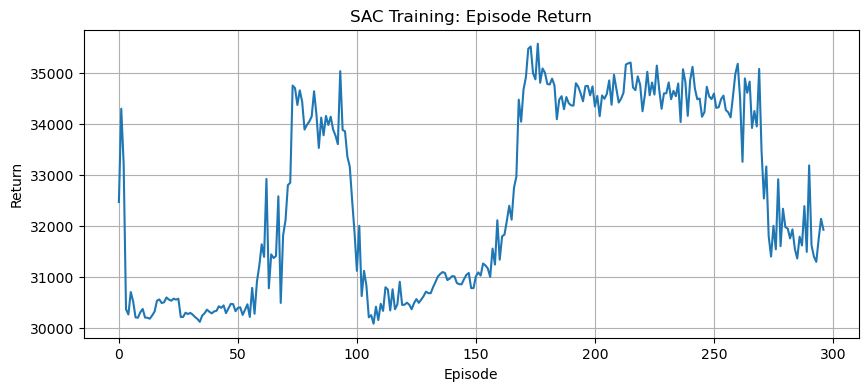

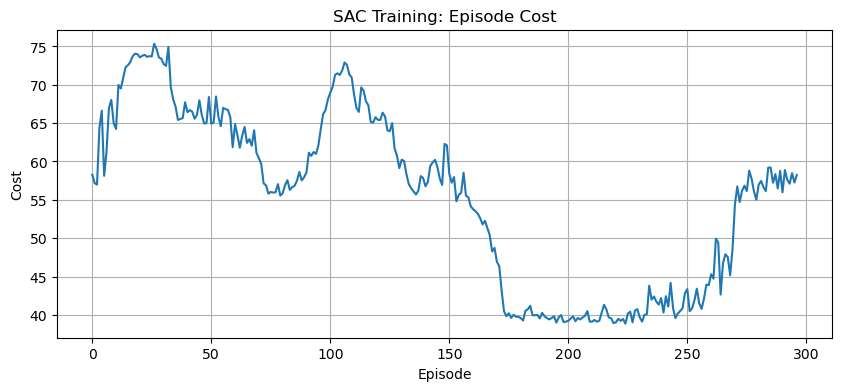

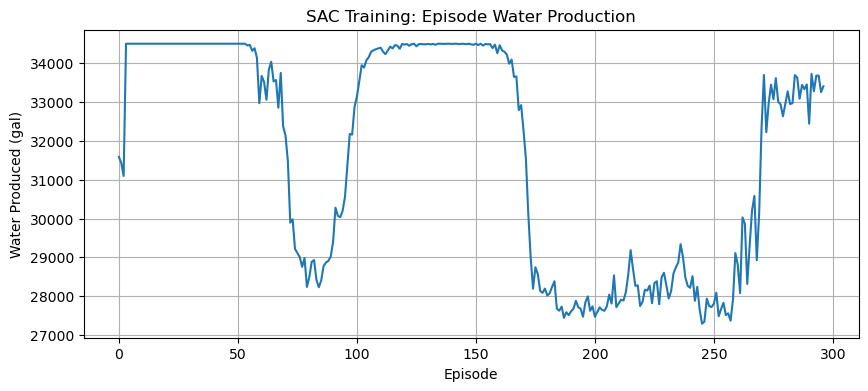

In [90]:
plt.figure(figsize=(10, 4))
plt.plot(train_logs["episode"], train_logs["episode_return"])
plt.title("SAC Training: Episode Return")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(train_logs["episode"], train_logs["episode_cost"])
plt.title("SAC Training: Episode Cost")
plt.xlabel("Episode")
plt.ylabel("Cost")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(train_logs["episode"], train_logs["episode_water"])
plt.title("SAC Training: Episode Water Production")
plt.xlabel("Episode")
plt.ylabel("Water Produced (gal)")
plt.grid(True)
plt.show()

In [91]:
def run_policy_episode(env, agent=None, deterministic=True, tariff_name=None):
    state = env.reset(tariff_name=tariff_name)

    done = False
    rows = []

    while not done:
        if agent is None:
            raw_action = np.zeros(env.action_dim, dtype=np.float32)
        else:
            raw_action = agent.select_action(state, deterministic=deterministic)

        next_state, reward, done, info = env.step(raw_action)

        rows.append({
            "hour": env.t,
            "reward": reward,
            **info
        })

        state = next_state

    return pd.DataFrame(rows)


eval_df = run_policy_episode(env, agent, deterministic=True)
eval_df.head()

,hour,reward,tariff_name,q_perm_gpm,q_conc_gpm,q_recirc_gpm,power_w,power_kw,price,step_cost,water_gal,cumulative_gal,target_total_gal,backlog,smooth_penalty,violation_penalty,terminal_prod_penalty,recovery
0,1,241.864287,simple_tou,3.45,3.350000,0.149320,1922.595021,1.922595,0.1,0.192260,207.0,207.0,27216.0,0.000003,1.428248,0.0,0.0,0.507353
1,2,397.639278,simple_tou,3.90,4.100000,0.043414,2451.592085,2.451592,0.1,0.245159,234.0,441.0,27216.0,0.000018,0.776216,0.0,0.0,0.487500
2,3,400.301207,simple_tou,3.90,4.508405,0.029183,2523.666315,2.523666,0.1,0.252367,234.0,675.0,27216.0,0.000048,0.166997,0.0,0.0,0.463822
3,4,401.009970,simple_tou,3.90,4.577340,0.029603,2537.159717,2.537160,0.1,0.253716,234.0,909.0,27216.0,0.000092,0.004752,0.0,0.0,0.460050
4,5,400.980995,simple_tou,3.90,4.581309,0.032326,2538.445562,2.538446,0.1,0.253845,234.0,1143.0,27216.0,0.000150,0.000023,0.0,0.0,0.459835


In [92]:
def run_data_baseline_episode(env, data):
    """Baseline: fixed PI setpoint, bypasses safety layer to stay exactly at 2.7."""
    state = env.reset()
    done  = False
    rows  = []

    fixed_action = data.baseline_action.copy()  # [2.7, 0.7, 2.0]

    while not done:
        action = data.feasible_region.clip(fixed_action)
        q_perm, q_conc, q_recirc = action

        power_w   = data.power_surrogate.predict_watts(action)
        power_kw  = power_w / 1000.0
        water_gal = q_perm * 60.0 * env.cfg.control_dt_hours
        price     = env._current_price()
        step_cost = price * power_kw * env.cfg.control_dt_hours

        env.cumulative_gal += water_gal
        env.prev_action     = action.copy()
        env.current_action  = action.copy()
        env.current_power_w = power_w
        env.t  += 1
        done    = env.t >= env.cfg.episode_hours
        next_state = env._get_state()

        info = {
            "tariff_name":       env.tariff_name,
            "q_perm_gpm":        float(q_perm),
            "q_conc_gpm":        float(q_conc),
            "q_recirc_gpm":      float(q_recirc),
            "power_w":           float(power_w),
            "power_kw":          float(power_kw),
            "price":             float(price),
            "step_cost":         float(step_cost),
            "water_gal":         float(water_gal),
            "cumulative_gal":    float(env.cumulative_gal),
            "target_total_gal":  float(data.target_total_gal),
            "backlog":           0.0,
            "smooth_penalty":    0.0,
            "violation_penalty": 0.0,
            "recovery":          float(q_perm / max(q_perm + q_conc, 1e-6)),
        }

        rows.append({"hour": env.t, "reward": 0.0, **info})
        state = next_state

    return pd.DataFrame(rows)


eval_df     = run_policy_episode(env, agent, deterministic=True)
baseline_df = run_data_baseline_episode(env, data)

print("RL cost:            ", eval_df["step_cost"].sum())
print("Baseline cost:      ", baseline_df["step_cost"].sum())
print("RL water (gal):     ", eval_df["water_gal"].sum())
print("Baseline water(gal):", baseline_df["water_gal"].sum())
print("RL final backlog:   ", eval_df["backlog"].iloc[-1])
print("Baseline backlog:   ", baseline_df["backlog"].iloc[-1])

RL cost:             59.24880645069534
Baseline cost:       44.85369744261849
RL water (gal):      33880.34439417275
Baseline water(gal): 27216.0
RL final backlog:    0.05996064164107503
Baseline backlog:    0.0


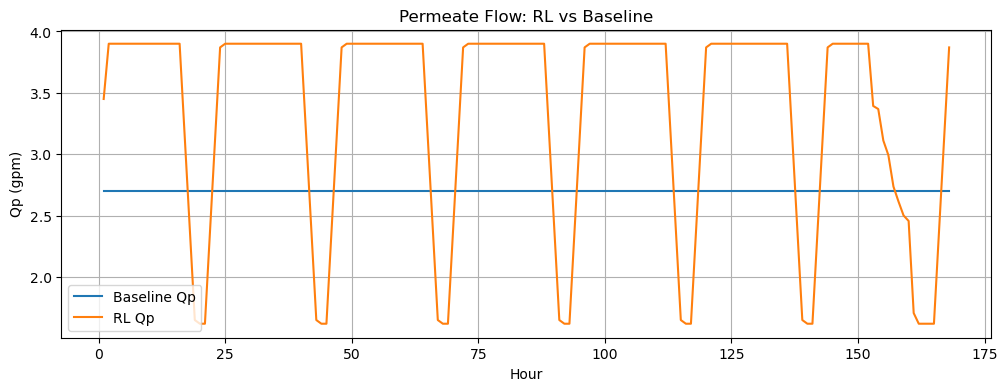

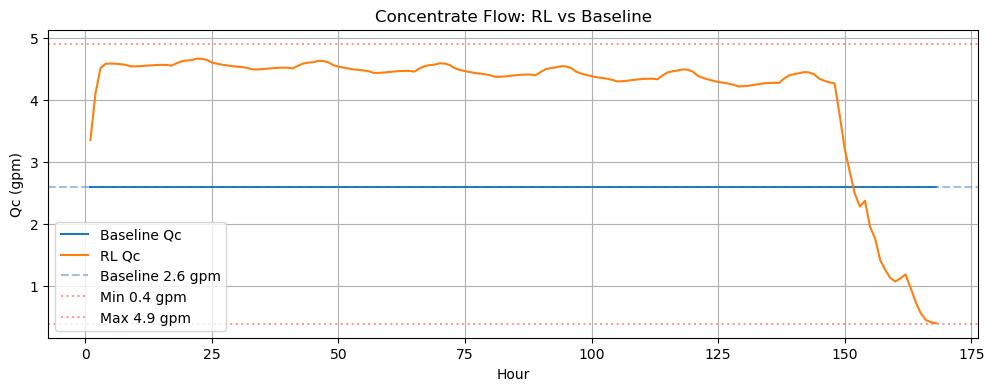

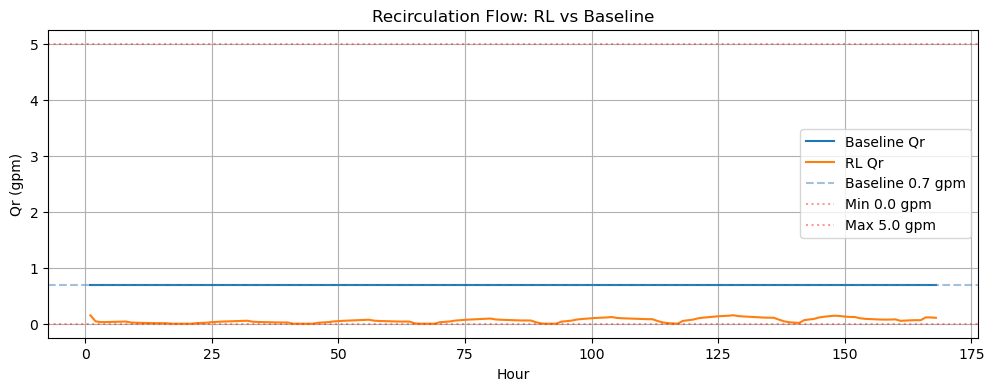

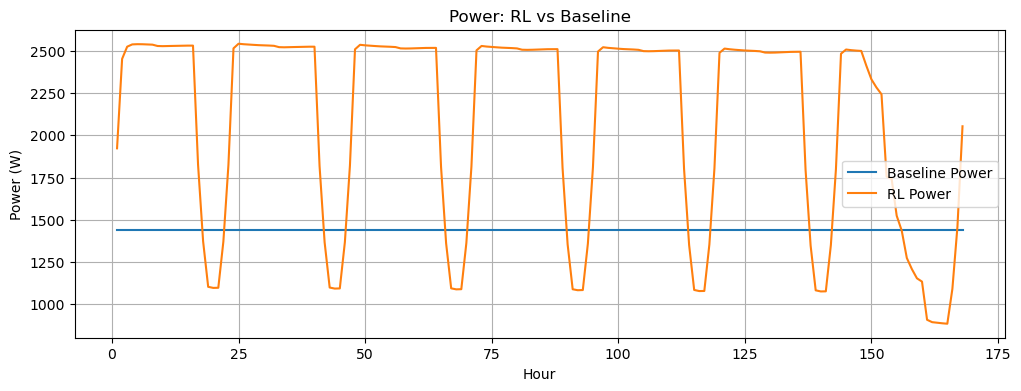

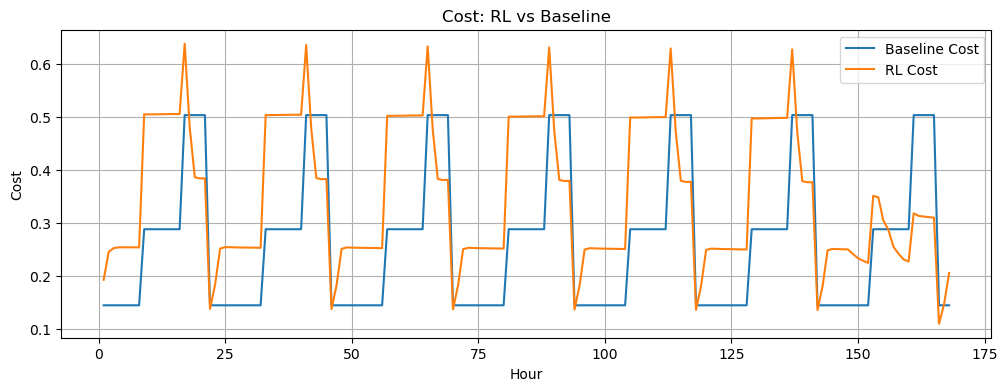


── Weekly Summary ──────────────────────────────
RL total cost:       $59.249
Baseline total cost: $44.854
Savings:             $-14.395  (-32.1%)
RL water:            33880 gal
Baseline water:      27216 gal

── Integral / Area Under Curve Summary ─────────

Flowrate Integrals (gpm·hr)
Baseline Qp integral: 453.60
RL Qp integral:       564.67
Qp difference:        111.07
Qp percent diff:      24.49%
Goal: RL Qp integral should be approximately equal to Baseline Qp integral.

Baseline Qc integral: 436.80
RL Qc integral:       689.03
Qc difference:        252.23

Baseline Qr integral: 117.60
RL Qr integral:       9.81
Qr difference:        -107.79

Power Integral (Wh)
Baseline Power integral: 241907.58 Wh
RL Power integral:       353065.66 Wh
Power difference:        111158.07 Wh
Power percent diff:      45.95%
Goal: RL Power integral should be below Baseline Power integral.

Cost Integral / Total Cost
Baseline Cost integral: $44.854
RL Cost integral:       $59.249
Cost difference:    

In [93]:
# ── Permeate Flow ────────────────────────────────────────── #
plt.figure(figsize=(12, 4))
plt.plot(baseline_df["hour"], baseline_df["q_perm_gpm"], label="Baseline Qp")
plt.plot(eval_df["hour"], eval_df["q_perm_gpm"], label="RL Qp")
plt.title("Permeate Flow: RL vs Baseline")
plt.xlabel("Hour")
plt.ylabel("Qp (gpm)")
plt.grid(True)
plt.legend()
plt.show()

# ── Concentrate Flow ──────────────────────────────────────────
plt.figure(figsize=(12, 4))
plt.plot(baseline_df["hour"], baseline_df["q_conc_gpm"], label="Baseline Qc")
plt.plot(eval_df["hour"],     eval_df["q_conc_gpm"],     label="RL Qc")
plt.axhline(y=2.6, color="steelblue", linestyle="--", alpha=0.5, label="Baseline 2.6 gpm")
plt.axhline(y=0.4, color="red",       linestyle=":",  alpha=0.4, label="Min 0.4 gpm")
plt.axhline(y=4.9, color="red",       linestyle=":",  alpha=0.4, label="Max 4.9 gpm")
plt.title("Concentrate Flow: RL vs Baseline")
plt.xlabel("Hour")
plt.ylabel("Qc (gpm)")
plt.grid(True)
plt.legend()
plt.show()

# ── Recirculation Flow ────────────────────────────────────────
plt.figure(figsize=(12, 4))
plt.plot(baseline_df["hour"], baseline_df["q_recirc_gpm"], label="Baseline Qr")
plt.plot(eval_df["hour"],     eval_df["q_recirc_gpm"],     label="RL Qr")
plt.axhline(y=0.7, color="steelblue", linestyle="--", alpha=0.5, label="Baseline 0.7 gpm")
plt.axhline(y=0.0, color="red",       linestyle=":",  alpha=0.4, label="Min 0.0 gpm")
plt.axhline(y=5.0, color="red",       linestyle=":",  alpha=0.4, label="Max 5.0 gpm")
plt.title("Recirculation Flow: RL vs Baseline")
plt.xlabel("Hour")
plt.ylabel("Qr (gpm)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(baseline_df["hour"], baseline_df["power_w"], label="Baseline Power")
plt.plot(eval_df["hour"], eval_df["power_w"], label="RL Power")
plt.title("Power: RL vs Baseline")
plt.xlabel("Hour")
plt.ylabel("Power (W)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(baseline_df["hour"], baseline_df["step_cost"], label="Baseline Cost")
plt.plot(eval_df["hour"], eval_df["step_cost"], label="RL Cost")
plt.title("Cost: RL vs Baseline")
plt.xlabel("Hour")
plt.ylabel("Cost")
plt.grid(True)
plt.legend()
plt.show()

print("\n── Weekly Summary ──────────────────────────────")
print(f"RL total cost:       ${eval_df['step_cost'].sum():.3f}")
print(f"Baseline total cost: ${baseline_df['step_cost'].sum():.3f}")
savings = baseline_df['step_cost'].sum() - eval_df['step_cost'].sum()
savings_pct = 100.0 * savings / baseline_df['step_cost'].sum()
print(f"Savings:             ${savings:.3f}  ({savings_pct:.1f}%)")
print(f"RL water:            {eval_df['water_gal'].sum():.0f} gal")
print(f"Baseline water:      {baseline_df['water_gal'].sum():.0f} gal")

# ── Integral / Area Under Curve Summary ──────────────────────

DT_HOURS = 1.0  # because this RL model is hourly

def auc_integral(df, col, dt=DT_HOURS):
    return float(np.sum(df[col].to_numpy()) * dt)

# Flow integrals: gpm * hr
baseline_qp_int = auc_integral(baseline_df, "q_perm_gpm")
rl_qp_int       = auc_integral(eval_df, "q_perm_gpm")

baseline_qc_int = auc_integral(baseline_df, "q_conc_gpm")
rl_qc_int       = auc_integral(eval_df, "q_conc_gpm")

baseline_qr_int = auc_integral(baseline_df, "q_recirc_gpm")
rl_qr_int       = auc_integral(eval_df, "q_recirc_gpm")

# Power integral: W * hr = Wh
baseline_power_int = auc_integral(baseline_df, "power_w")
rl_power_int       = auc_integral(eval_df, "power_w")

# Cost integral: cost already per hour, so sum = total weekly cost
baseline_cost_int = auc_integral(baseline_df, "step_cost")
rl_cost_int       = auc_integral(eval_df, "step_cost")

print("\n── Integral / Area Under Curve Summary ─────────")

print("\nFlowrate Integrals (gpm·hr)")
print(f"Baseline Qp integral: {baseline_qp_int:.2f}")
print(f"RL Qp integral:       {rl_qp_int:.2f}")
print(f"Qp difference:        {rl_qp_int - baseline_qp_int:.2f}")
print(f"Qp percent diff:      {100 * (rl_qp_int - baseline_qp_int) / baseline_qp_int:.2f}%")
print("Goal: RL Qp integral should be approximately equal to Baseline Qp integral.")

print(f"\nBaseline Qc integral: {baseline_qc_int:.2f}")
print(f"RL Qc integral:       {rl_qc_int:.2f}")
print(f"Qc difference:        {rl_qc_int - baseline_qc_int:.2f}")

print(f"\nBaseline Qr integral: {baseline_qr_int:.2f}")
print(f"RL Qr integral:       {rl_qr_int:.2f}")
print(f"Qr difference:        {rl_qr_int - baseline_qr_int:.2f}")

print("\nPower Integral (Wh)")
print(f"Baseline Power integral: {baseline_power_int:.2f} Wh")
print(f"RL Power integral:       {rl_power_int:.2f} Wh")
print(f"Power difference:        {rl_power_int - baseline_power_int:.2f} Wh")
print(f"Power percent diff:      {100 * (rl_power_int - baseline_power_int) / baseline_power_int:.2f}%")
print("Goal: RL Power integral should be below Baseline Power integral.")

print("\nCost Integral / Total Cost")
print(f"Baseline Cost integral: ${baseline_cost_int:.3f}")
print(f"RL Cost integral:       ${rl_cost_int:.3f}")
print(f"Cost difference:        ${rl_cost_int - baseline_cost_int:.3f}")
print(f"Cost percent diff:      {100 * (rl_cost_int - baseline_cost_int) / baseline_cost_int:.2f}%")
print("Goal: RL Cost integral should be below Baseline Cost integral.")

In [94]:
import os

os.makedirs("../models", exist_ok=True)
os.makedirs("../models/rl_outputs", exist_ok=True)

torch.save(
    {
        "policy": agent.policy.state_dict(),
        "q1": agent.q1.state_dict(),
        "q2": agent.q2.state_dict(),
        "q1_target": agent.q1_target.state_dict(),
        "q2_target": agent.q2_target.state_dict(),
        "log_alpha": agent.log_alpha.detach().cpu().item(),
    },
    "../models/rl_outputs/sac_ro_agent.pt"
)

train_logs.to_csv("../models/rl_outputs/train_logs.csv", index=False)
eval_df.to_csv("../models/rl_outputs/eval_policy.csv", index=False)
baseline_df.to_csv("../models/rl_outputs/baseline_policy.csv", index=False)

print("Saved RL outputs to ../models/rl_outputs/")

Saved RL outputs to ../models/rl_outputs/
